### Chain Using Langgraph

In [1]:
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

load_dotenv()

langfuse_trace = CallbackHandler()


In [2]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding", name="Tho"))

messages.append(AIMessage(
    content=f"Which programming language you want to learn",
    name="LLMModel",
))
messages.append(HumanMessage(content=f"I want to learn Python programming language", name="Tho"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Tho

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Tho

I want to learn Python programming language


In [ ]:
### Using ChatGroq

# from langchain_groq import ChatGroq

# llm = ChatGroq(
#     model="llama-3.1-8b-instant"
# )
# result = llm.invoke(messages, config={'callbacks': [langfuse_trace]})

In [4]:
### Local Ollama
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="granite4",
    temperature=0,
)
result = llm.invoke(messages, config={'callbacks': [langfuse_trace]})

In [5]:
result.response_metadata

{'model': 'granite4',
 'created_at': '2026-06-25T03:40:38.405351481Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 54737470350,
 'load_duration': 24990879232,
 'prompt_eval_count': 49,
 'prompt_eval_duration': 657461000,
 'eval_count': 351,
 'eval_duration': 29083836000,
 'logprobs': None,
 'model_name': 'granite4',
 'model_provider': 'ollama'}

### ToolCalling

In [6]:
def add(a: int, b: int) -> int:
    """
    Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a + b

In [7]:
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, model='granite4', temperature=0.0)

In [8]:
### Binding tools with llm
llm_with_tools = llm.bind_tools([add])
tool_call = llm_with_tools.invoke(
    [HumanMessage(content=f"What is 2 plus 2?", name="Tho")],
    config={"callbacks": [langfuse_trace]}
)

In [9]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'b': 2, 'a': 2},
  'id': '968a3f98-1bcf-4625-b836-6accc8d1c92e',
  'type': 'tool_call'}]

### Using messages as state

In [10]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    name: str

### Reducers with add_messages

In [11]:
initial_messages=[AIMessage(content=f"Please tell me how can I help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name="Tho"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Tho')]

In [12]:
ai_message = AIMessage(
    content=f"Which programming language you want to learn",
    name="LLMModel",
)
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [13]:
### Reducers add_messages is to append instead of override.
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='5038a3f9-f576-4646-b46b-bd0c353870ab', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Tho', id='859280f7-f5d5-4ae6-aa5f-b4ad3708b8df'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='695f755c-853d-43e9-a80b-e9e3963b8a2b', tool_calls=[], invalid_tool_calls=[])]

In [14]:
## chatbot node functionality

def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

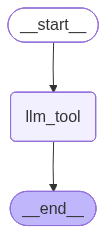

In [15]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph  = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
## invocation
messages = graph.invoke({
    "messages": "What is 2 plus 2?"
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2?
================================== Ai Message ==================================
Tool Calls:
  add (22bbda77-ef87-4570-9b0d-00a39645d0b0)
 Call ID: 22bbda77-ef87-4570-9b0d-00a39645d0b0
  Args:
    a: 2
    b: 2


In [17]:
tools=[add]

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition

builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()


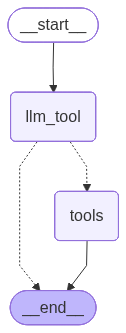

In [20]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [21]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (16f41e3e-4465-47e1-b538-8a9c62e23a92)
 Call ID: 16f41e3e-4465-47e1-b538-8a9c62e23a92
  Args:
    a: 2
    b: 2


In [22]:
## invocation

messages=graph.invoke({"messages":"What is Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================

Machine learning (ML) is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data—improving their performance at some task over time without being explicitly programmed for each specific step.

### Core Concepts

| Concept | Description |
|---------|-------------|
| **Learning** | The process by which algorithms adjust internal parameters to minimize error when making predictions or decisions based on input data. |
| **Data** | The foundation of ML; high-quality, relevant datasets enable better learning outcomes. |
| **Model** | A mathematical representation (e.g., a neural network, decision tree, linear regression) that captures patterns from the training data. |
| **Training / Fitting** | Using labeled examples to adjust model parameters so it can generaliz